# Assignment

> Add blockquote



## Problem Statement:
Study analysis on the public sentiment towards a company and its stock effect their prices by extracting opinions from Twitter in determining whether public opinion has impact on the stock prices of the company.

In [151]:
import pandas as pd
import numpy as np

path = "dataset.csv"
df = pd.read_csv(path)

# Creating a small sample for faster processing during the notebook
# df = df.head(100000).copy()

print(f"Using sample size: {len(df):,}")
print(df.head())

C:\Users\hafiz\AppData\Local\Temp\ipykernel_21804\2615617578.py:5: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path)


Using sample size: 1,395,450
  Unnamed: 0                                              TWEET       STOCK  \
0          0  RT @robertoglezcano: @amazon  #Patents Show Fl...         NaN   
1        NaN                                             Amazon  31/01/2017   
2          1  @FAME95FM1 Jamaicans make money with @Payoneer...      PayPal   
3          2  @CBSi Jamaicans make money with @Payoneer @Pay...      PayPal   
4          3  @Hitz92fm Jamaicans make money with @Payoneer ...      PayPal   

         DATE  LAST_PRICE  1_DAY_RETURN  2_DAY_RETURN  3_DAY_RETURN  \
0         NaN         NaN           NaN           NaN           NaN   
1      823.48    0.008379      0.014924      0.014924     -0.001263   
2  31/01/2017   39.780000      0.002011      0.012318      0.012318   
3  31/01/2017   39.780000      0.002011      0.012318      0.012318   
4  31/01/2017   39.780000      0.002011      0.012318      0.012318   

   7_DAY_RETURN    PX_VOLUME  VOLATILITY_10D  VOLATILITY_30D  LSTM_PO

### Basic Descriptive Statistics

In [152]:
print("Describe: ", df.describe())

Describe:            LAST_PRICE   1_DAY_RETURN   2_DAY_RETURN  3_DAY_RETURN  \
count  862231.000000  862231.000000  862231.000000  8.622310e+05   
mean      716.123477       0.001473       0.002579  3.262616e+06   
std      4731.498118       0.023068       0.032594  1.053913e+07   
min        -0.173554      -0.177851      -0.204959 -2.049587e-01   
25%         0.000000      -0.007511      -0.011456 -8.465608e-03   
50%         0.014220       0.000000       0.000000  1.019542e-02   
75%       115.600000       0.008192       0.013911  6.545426e-02   
max    165500.000000       0.243639       0.267113  3.081068e+08   

       7_DAY_RETURN     PX_VOLUME  VOLATILITY_10D  VOLATILITY_30D  \
count  8.622310e+05  8.622310e+05   862130.000000   862184.000000   
mean   6.201036e+06  7.522187e+06       18.293836       10.738204   
std    1.388221e+07  1.591847e+07       16.277630       14.693986   
min   -2.049587e-01  1.000000e+00       -1.000000       -1.000000   
25%    5.474453e-03  2.051700e+

In [153]:
df.isnull().sum()

Unnamed: 0            293437
TWEET                     52
STOCK                 533219
DATE                  533219
LAST_PRICE            533219
1_DAY_RETURN          533219
2_DAY_RETURN          533219
3_DAY_RETURN          533219
7_DAY_RETURN          533219
PX_VOLUME             533219
VOLATILITY_10D        533320
VOLATILITY_30D        533266
LSTM_POLARITY         734348
TEXTBLOB_POLARITY    1027785
dtype: int64

In [154]:
df = df.dropna(subset="TWEET")
df.isnull().sum()

Unnamed: 0            293437
TWEET                      0
STOCK                 533167
DATE                  533167
LAST_PRICE            533167
1_DAY_RETURN          533167
2_DAY_RETURN          533167
3_DAY_RETURN          533167
7_DAY_RETURN          533167
PX_VOLUME             533167
VOLATILITY_10D        533268
VOLATILITY_30D        533214
LSTM_POLARITY         734296
TEXTBLOB_POLARITY    1027733
dtype: int64

In [155]:
print(df['LSTM_POLARITY'].unique())
print(df['TEXTBLOB_POLARITY'].unique())

[        nan  0.         -1.         ... -0.15277778  0.50729167
  0.55885417]
[        nan  0.          0.2        ...  0.67708333  0.23111111
 -0.12797619]


In [156]:
lstm_counts = df['LSTM_POLARITY'].value_counts()
textblob_counts = df['TEXTBLOB_POLARITY'].value_counts()

print("LSTM Distribution:\n", lstm_counts)
print("\nTextBlob Distribution:\n", textblob_counts)

LSTM Distribution:
 LSTM_POLARITY
 1.000000    209836
-1.000000    162613
 0.000000    154342
 0.136364     21340
 0.500000      9469
              ...  
 0.237143         1
-0.857143         1
 0.047273         1
-0.022321         1
 0.568750         1
Name: count, Length: 2775, dtype: int64

TextBlob Distribution:
 TEXTBLOB_POLARITY
 0.000000    191878
 0.500000     14745
 0.250000      8104
 0.200000      7812
 0.136364      7630
              ...  
-0.067708         1
-0.520833         1
 0.141026         1
-0.012698         1
 0.161538         1
Name: count, Length: 3375, dtype: int64


In [157]:
import sys
print(sys.executable)

c:\Users\hafiz\AppData\Local\Programs\Python\Python313\python.exe


In [158]:
!{sys.executable} -m pip install matplotlib


[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


LSTM_sentiment
Neutral     888638
Positive    307431
Negative    199329
Name: count, dtype: int64


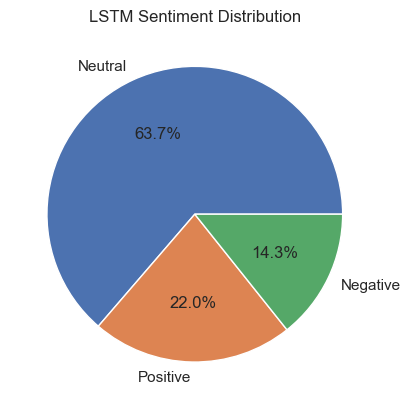

In [159]:
def categorize_lstm(score):
    if score > 0:
        return "Positive"
    elif score < 0:
        return "Negative"
    else:
        return "Neutral"

df['LSTM_sentiment'] = df['LSTM_POLARITY'].apply(categorize_lstm)

lstm_counts = df['LSTM_sentiment'].value_counts()
print(lstm_counts)

import matplotlib.pyplot as plt

plt.figure()
plt.pie(lstm_counts, labels=lstm_counts.index, autopct='%1.1f%%')
plt.title("LSTM Sentiment Distribution")
plt.show()

### Metada Analysis

In [160]:
#if sentiment analysis has more neutral than +ve & -ve, there is issue in dataset
print(df.columns)
print(df['STOCK'].value_counts())


Index(['Unnamed: 0', 'TWEET', 'STOCK', 'DATE', 'LAST_PRICE', '1_DAY_RETURN',
       '2_DAY_RETURN', '3_DAY_RETURN', '7_DAY_RETURN', 'PX_VOLUME',
       'VOLATILITY_10D', 'VOLATILITY_30D', 'LSTM_POLARITY',
       'TEXTBLOB_POLARITY', 'LSTM_sentiment'],
      dtype='object')
STOCK
Ford        52198
Facebook    40837
Google      33697
Next        32606
Apple       27940
            ...  
33.3            1
536.9           1
15.61           1
5468.0          1
1028.0          1
Name: count, Length: 4241, dtype: int64


In [161]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"[^a-z\s]", "", text)
    return text

df['cleaned_tweet'] = df['TWEET'].apply(clean_text)

In [162]:
!{sys.executable} -m pip install nltk


[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [163]:
### Remove Stopword
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords
from collections import Counter

stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"[^a-z\s]", "", text)
    words = text.split()
    words = [w for w in words if w not in stop_words and len(w) > 2]
    return words

all_words = []

for tweet in df['TWEET']:
    all_words.extend(clean_text(tweet))

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\hafiz\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [164]:
word_counts = Counter(all_words)
top_words = word_counts.most_common(15)

words = [w[0] for w in top_words]
counts = [w[1] for w in top_words]

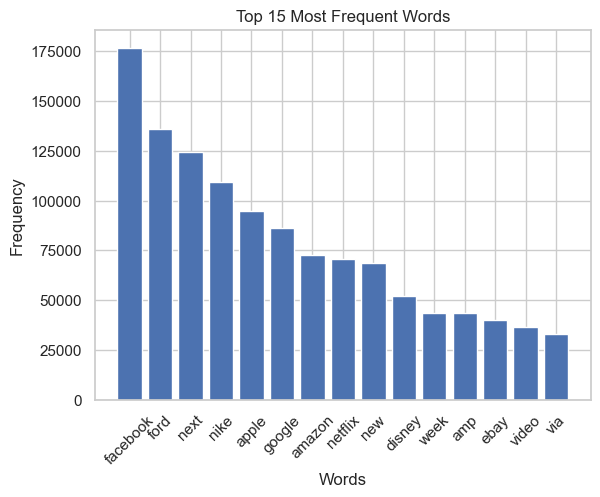

In [165]:
### Plotting
import matplotlib.pyplot as plt

plt.figure()
plt.bar(words, counts)
plt.xticks(rotation=45)
plt.title("Top 15 Most Frequent Words")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.show()

In [166]:
!pip install textblob


[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [167]:
from textblob import TextBlob

def get_polarity(text):
    return TextBlob(text).sentiment.polarity

df['calculated_polarity'] = df['TWEET'].apply(get_polarity)

In [168]:
def categorize_sentiment(score):
    if score > 0:
        return "Positive"
    elif score < 0:
        return "Negative"
    else:
        return "Neutral"

df['sentiment'] = df['calculated_polarity'].apply(categorize_sentiment)

In [169]:
sentiment_counts = df['sentiment'].value_counts()
print(sentiment_counts)

sentiment
Neutral     918481
Positive    342309
Negative    134608
Name: count, dtype: int64


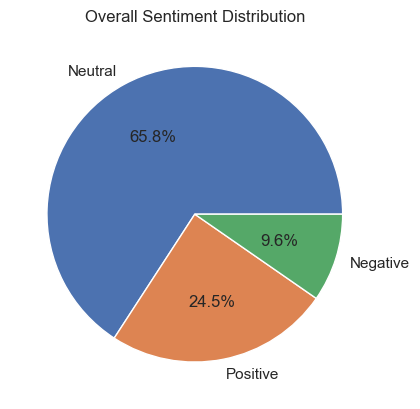

In [170]:
plt.figure()
plt.pie(sentiment_counts, labels=sentiment_counts.index, autopct='%1.1f%%')
plt.title("Overall Sentiment Distribution")
plt.show()

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\hafiz\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


vader_sentiment
Neutral     857457
Positive    339927
Negative    198014
Name: count, dtype: int64


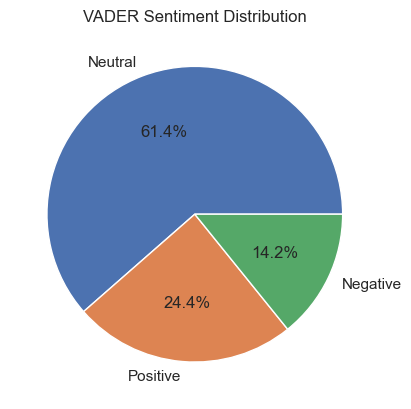

In [171]:
from nltk.sentiment import SentimentIntensityAnalyzer
nltk.download('vader_lexicon')

sia = SentimentIntensityAnalyzer()

def get_sentiment(text):
    score = sia.polarity_scores(text)['compound']
    if score > 0.05:
        return "Positive"
    elif score < -0.05:
        return "Negative"
    else:
        return "Neutral"

df['vader_sentiment'] = df['TWEET'].apply(get_sentiment)

vader_counts = df['vader_sentiment'].value_counts()
print(vader_counts)

import matplotlib.pyplot as plt

plt.figure()
plt.pie(vader_counts, labels=vader_counts.index, autopct='%1.1f%%')
plt.title("VADER Sentiment Distribution")
plt.show()

### Preprocessing Pipeline

#### Sentence Segmentation

In [172]:
import nltk

from nltk.tokenize import sent_tokenize

# Download the required NLTK resources
nltk.download('punkt')      # Rules for tokenization (chopping text)
nltk.download('punkt_tab')  # NEW requirement for tokenization in updated NLTK versions
nltk.download('stopwords')  # List of common, uninformative words
nltk.download('wordnet')    # Massive English dictionary for Lemmatization
nltk.download('omw-1.4')    # Supporting data for WordNet

print("NLTK Resources Downloaded Successfully!")


NLTK Resources Downloaded Successfully!


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\hafiz\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\hafiz\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\hafiz\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\hafiz\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\hafiz\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [173]:

# Sentence Segmentation
df["sentences"] = df["TWEET"].apply(sent_tokenize)



In [174]:
for i, s in enumerate(df["sentences"].iloc[194]):
    print(f"Sentence {i+1}: {s}")

Sentence 1: RT @cultcommoncore: Dumping @Starbucks
Is like dropping cable tv.
Sentence 2: You wonder how you paid 
SO much
For such crap
For SO long.…


#### Handling Abbreviations

In [175]:
import re
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer

In [176]:
# Abbreviation Dictionary
abbreviation_dict = {
    "rt": "retweet",
    "roi": "return on investment",
    "vix": "volatility index",
    "u": "you",
    "ur": "your",
    "w/": "with",
    "dm": "direct message",
    "fb": "facebook",
    "ig": "instagram",
    "li": "linkedin",
    "yt": "youtube",
    "omg": "oh my god",
    "lol": "laugh out loud"
}

#### Tokenization

In [177]:
def tokenize_and_clean(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)
    tokens = word_tokenize(text)

    expanded_tokens = []
    for word in tokens:
        expanded_word = abbreviation_dict.get(word, word)
        expanded_tokens.extend(expanded_word.split())

    clean_tokens = [word for word in expanded_tokens if word.isalpha()]
    return clean_tokens

In [178]:
def expand_abbreviations(token_list):
  expanded_tokens = []
  for word in token_list:
    # if word in dict, replace it
    expanded_word = abbreviation_dict.get(word.lower(), word)
    expanded_tokens.append(expanded_word.split())
  return expanded_tokens

df["tokens"] = df["TWEET"].apply(tokenize_and_clean)
df["expanded_tokens"] = df["tokens"].apply(expand_abbreviations)

In [179]:
df['expanded_tokens']

0          [[retweet], [robertoglezcano], [amazon], [pate...
1                                                 [[amazon]]
2          [[jamaicans], [make], [money], [with], [payone...
3          [[cbsi], [jamaicans], [make], [money], [with],...
4          [[jamaicans], [make], [money], [with], [payone...
                                 ...                        
1395445                                           [[paypal]]
1395446    [[retweet], [rifatjawaid], [deceased], [apple]...
1395447                                            [[apple]]
1395448    [[flat], [inr], [cashback], [on], [hdfc], [deb...
1395449                                          [[samsung]]
Name: expanded_tokens, Length: 1395398, dtype: object

#### Stopword Removal

In [180]:
from nltk.corpus import stopwords

# Load the English stopwords list
stop_words = set(stopwords.words('english'))

# We can also add custom stopwords specific to our dataset if we want
custom_stopwords = ['next', 'via', 'amp']
stop_words.update(custom_stopwords)

def remove_stopwords(token_list):
    # Keep the word ONLY if it is not in our stop_words list
    filtered_tokens = [word for word in token_list if word not in stop_words]
    return filtered_tokens

# Apply to our tokens
df['filtered_tokens'] = df['tokens'].apply(remove_stopwords)

# Compare the tokens before and after stopword removal
df[['tokens', 'filtered_tokens']].head()

,tokens,filtered_tokens
0,"[retweet, robertoglezcano, amazon, patents, sh...","[retweet, robertoglezcano, amazon, patents, sh..."
1,[amazon],[amazon]
2,"[jamaicans, make, money, with, payoneer, paypa...","[jamaicans, make, money, payoneer, paypal, pax..."
3,"[cbsi, jamaicans, make, money, with, payoneer,...","[cbsi, jamaicans, make, money, payoneer, paypa..."
4,"[jamaicans, make, money, with, payoneer, paypa...","[jamaicans, make, money, payoneer, paypal, pax..."


#### Stemming or Lemmatization

In [181]:
from nltk.stem import PorterStemmer, WordNetLemmatizer

# Initialize our two tools
stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()

def apply_stemming(token_list):
    return [stemmer.stem(word) for word in token_list]

def apply_lemmatization(token_list):
    return [lemmatizer.lemmatize(word) for word in token_list]

# Create two new columns to compare the results
df['stemmed_words'] = df['filtered_tokens'].apply(apply_stemming)
df['lemmatized_words'] = df['filtered_tokens'].apply(apply_lemmatization)

print("Stemming and Lemmatization complete!")

Stemming and Lemmatization complete!


#### POS Tagging

In [182]:
nltk.download('averaged_perceptron_tagger_eng')


#apply pos tag
df['pos_tags'] = df['lemmatized_words'].apply(nltk.pos_tag)



[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\hafiz\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


Named Entity Recognition (NER)

In [183]:
# nltk.download('maxent_ne_chunker_tab')
# nltk.download('words')

# def apply_ner(tagged_tokens):
#   return nltk.ne_chunk(tagged_tokens)

# df['ner'] = df['pos_tags'].apply(apply_ner)

#### Word Cloud Visualization

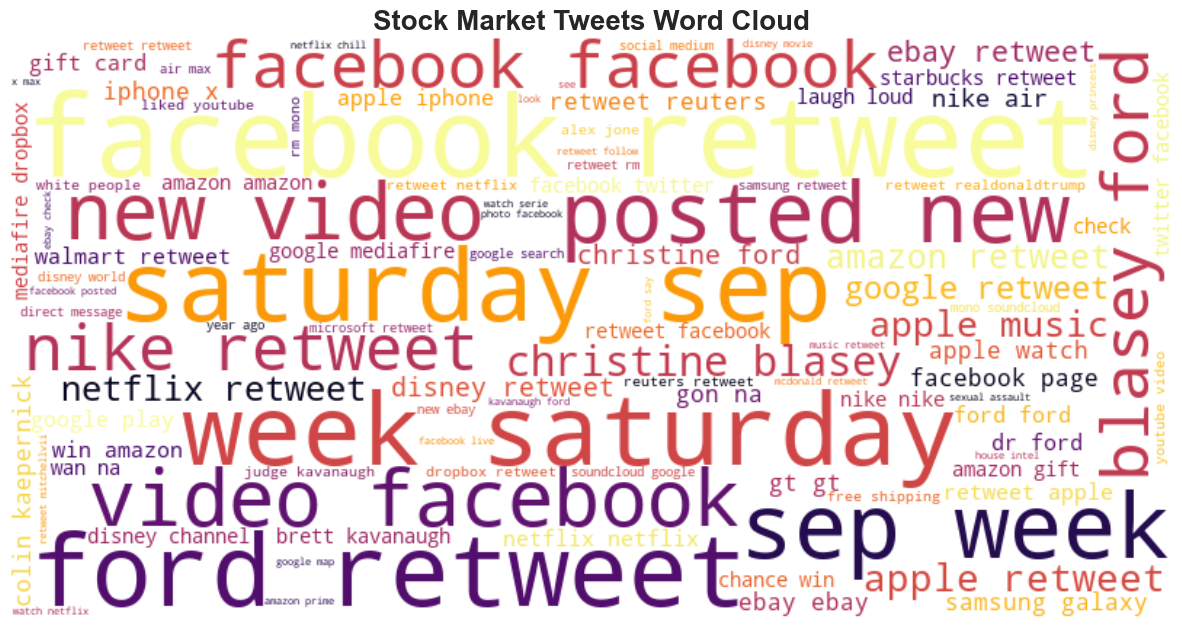

In [184]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

all_clean_words = []
for word_list in df['lemmatized_words']:
    all_clean_words.extend(word_list)

text_for_cloud = " ".join(all_clean_words)

# Generate the word cloud
wordcloud = WordCloud(width=800, height=400,
                      background_color='white',
                      colormap='inferno',
                      max_words=100).generate(text_for_cloud)

# Plot the image
plt.figure(figsize=(15, 8))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off") # Turn off the grid numbers
plt.title("Stock Market Tweets Word Cloud", fontsize=20, fontweight='bold')
plt.show()

pipeline comparison

In [185]:
# Select a random row (e.g., row index 5) to inspect
row_to_inspect = 200

print("1. ORIGINAL TEXT:")
print(df['TWEET'].iloc[row_to_inspect])
print("\n2. TOKENIZED & NOISE REMOVED:")
print(df['tokens'].iloc[row_to_inspect])
print("\n3. STOPWORDS REMOVED:")
print(df['filtered_tokens'].iloc[row_to_inspect])
print("\n4. STEMMED (Chopped endings):")
print(df['stemmed_words'].iloc[row_to_inspect])
print("\n5. LEMMATIZED (Dictionary root):")
print(df['lemmatized_words'].iloc[row_to_inspect])

1. ORIGINAL TEXT:
eBay

2. TOKENIZED & NOISE REMOVED:
['ebay']

3. STOPWORDS REMOVED:
['ebay']

4. STEMMED (Chopped endings):
['ebay']

5. LEMMATIZED (Dictionary root):
['ebay']


In [186]:
!{sys.executable} -m pip install scikit-learn seaborn afinn

import seaborn as sns
from afinn import Afinn
from sklearn.feature_extraction.text import TfidfVectorizer
from nltk.sentiment import SentimentIntensityAnalyzer
import nltk

nltk.download('vader_lexicon')

def get_sentiment_class(score, positive_threshold=0, negative_threshold=0):
    if score > positive_threshold:
        return 'Positive'
    elif score < negative_threshold:
        return 'Negative'
    return 'Neutral'

# Reuse lemmatized words when available so TF-IDF works on cleaner tokens.
if 'lemmatized_words' in df.columns:
    df['joined_tokens'] = df['lemmatized_words'].apply(lambda x: ' '.join(x) if isinstance(x, list) else '')
else:
    df['joined_tokens'] = df['TWEET'].fillna('').astype(str)

# TextBlob comparison column
df['textblob_polarity'] = df['joined_tokens'].apply(lambda text: TextBlob(text).sentiment.polarity)
df['textblob_sentiment'] = df['textblob_polarity'].apply(get_sentiment_class)

# VADER comparison column
sia = SentimentIntensityAnalyzer()
df['vader_score'] = df['TWEET'].fillna('').astype(str).apply(lambda text: sia.polarity_scores(text)['compound'])
df['vader_sentiment'] = df['vader_score'].apply(lambda score: get_sentiment_class(score, 0.05, -0.05))

# AFINN comparison column
afinn = Afinn()
df['afinn_score'] = df['joined_tokens'].apply(afinn.score)
df['afinn_sentiment'] = df['afinn_score'].apply(get_sentiment_class)

# Use the existing LSTM polarity labels to define sentiment groups for TF-IDF.
if 'LSTM_sentiment' not in df.columns and 'LSTM_POLARITY' in df.columns:
    df['LSTM_sentiment'] = df['LSTM_POLARITY'].apply(get_sentiment_class)

tfidf_vectorizer = TfidfVectorizer(max_features=1000, stop_words='english')
tfidf_matrix = tfidf_vectorizer.fit_transform(df['joined_tokens'])
feature_names = tfidf_vectorizer.get_feature_names_out()
# Ensure the TF-IDF DataFrame uses the same index as the original df so .loc with df indices works
df_tfidf = pd.DataFrame(tfidf_matrix.toarray(), columns=feature_names, index=df.index)

sentiment_order = ['Negative', 'Neutral', 'Positive']
sentiment_columns = ['textblob_sentiment', 'vader_sentiment', 'afinn_sentiment']
sentiment_summary = pd.DataFrame({
    'TextBlob': df['textblob_sentiment'].value_counts(),
    'VADER': df['vader_sentiment'].value_counts(),
    'AFINN': df['afinn_sentiment'].value_counts(),
}).reindex(sentiment_order).fillna(0).astype(int)

tfidf_group_column = 'LSTM_sentiment' if 'LSTM_sentiment' in df.columns else 'vader_sentiment'
tfidf_top_terms = {}
for sentiment in sentiment_order:
    group_index = df.index[df[tfidf_group_column] == sentiment]
    if len(group_index) == 0:
        tfidf_top_terms[sentiment] = pd.Series(dtype=float)
        continue

    mean_scores = df_tfidf.loc[group_index].mean().sort_values(ascending=False).head(10)
    tfidf_top_terms[sentiment] = mean_scores

comparison_table = df[[
    'TWEET', 'textblob_sentiment', 'vader_sentiment', 'afinn_sentiment'
]].head(15)

print('--- Sentiment Comparison Counts ---')
display(sentiment_summary)
print('\n--- Sample Tweet-Level Comparison ---')
display(comparison_table)



[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip
[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\hafiz\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


--- Sentiment Comparison Counts ---


,TextBlob,VADER,AFINN
Negative,128138,198014,198165
Neutral,939524,857457,919005
Positive,327736,339927,278228



--- Sample Tweet-Level Comparison ---


,TWEET,textblob_sentiment,vader_sentiment,afinn_sentiment
0,RT @robertoglezcano: @amazon #Patents Show Fl...,Neutral,Neutral,Neutral
1,Amazon,Neutral,Positive,Neutral
2,@FAME95FM1 Jamaicans make money with @Payoneer...,Neutral,Neutral,Neutral
3,@CBSi Jamaicans make money with @Payoneer @Pay...,Neutral,Neutral,Neutral
4,@Hitz92fm Jamaicans make money with @Payoneer ...,Neutral,Neutral,Neutral
5,RT @loadsofvans: Retweet this post &amp; follo...,Positive,Positive,Positive
6,Amazon,Neutral,Positive,Neutral
7,RT @Disney: See The Newest Trailer for #Beauty...,Neutral,Neutral,Neutral
8,Disney,Neutral,Neutral,Neutral
9,RT @tarastrong: Just got @facebook back! I REA...,Positive,Positive,Positive


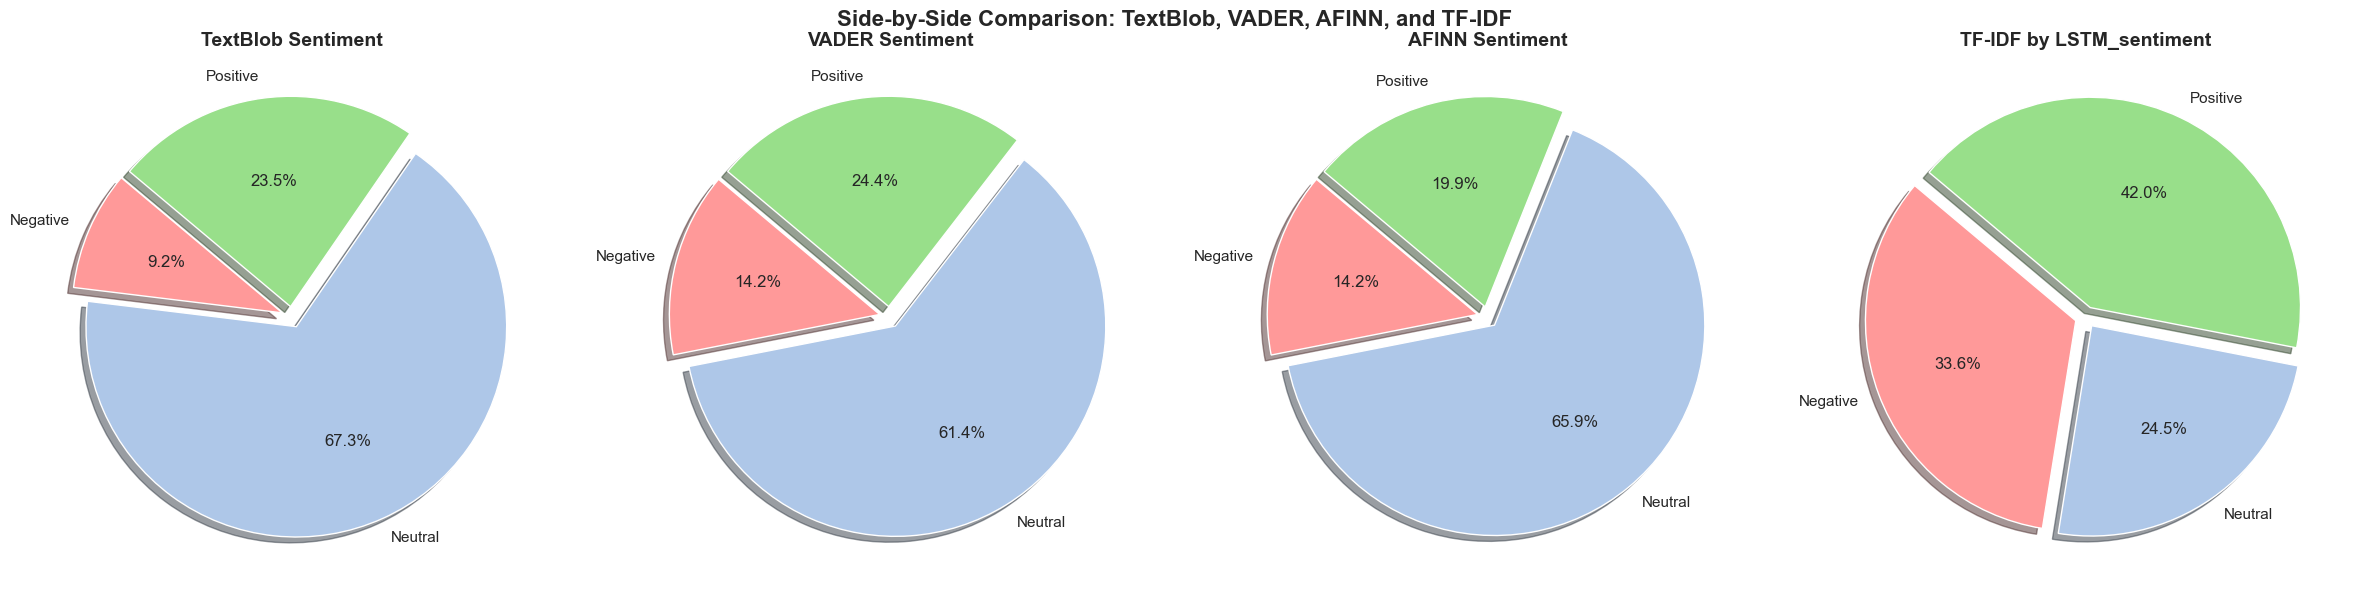

--- TF-IDF Top Terms by Sentiment Group ---


,Negative,Neutral,Positive
0,retweet (0.080),retweet (0.051),facebook (0.099)
1,ford (0.056),facebook (0.049),retweet (0.076)
2,facebook (0.051),ford (0.037),ford (0.059)
3,nike (0.048),nike (0.034),nike (0.041)
4,apple (0.035),apple (0.028),apple (0.039)
5,google (0.035),netflix (0.025),google (0.035)
6,netflix (0.025),google (0.024),amazon (0.033)
7,amazon (0.024),new (0.022),disney (0.028)
8,disney (0.014),week (0.022),netflix (0.028)
9,ebay (0.013),amazon (0.021),ebay (0.016)


In [187]:
sns.set_theme(style='whitegrid')
pie_palette = ['#ff9999', '#aec7e8', '#98df8a']
fig, axes = plt.subplots(1, 4, figsize=(24, 6))

method_columns = [
    ('TextBlob', 'textblob_sentiment'),
    ('VADER', 'vader_sentiment'),
    ('AFINN', 'afinn_sentiment'),
]

for ax, (method_name, column_name) in zip(axes[:3], method_columns):
    counts = df[column_name].value_counts().reindex(sentiment_order).fillna(0)
    ax.pie(
        counts,
        labels=counts.index,
        autopct='%1.1f%%',
        startangle=140,
        colors=pie_palette,
        explode=(0.05, 0.05, 0.05),
        shadow=True,
    )
    ax.set_title(f'{method_name} Sentiment', fontsize=14, fontweight='bold')

tfidf_sentiment_strength = pd.Series({
    sentiment: tfidf_top_terms[sentiment].head(3).sum()
    for sentiment in sentiment_order
}).reindex(sentiment_order).fillna(0)

if tfidf_sentiment_strength.sum() > 0:
    axes[3].pie(
        tfidf_sentiment_strength,
        labels=tfidf_sentiment_strength.index,
        autopct='%1.1f%%',
        startangle=140,
        colors=pie_palette,
        explode=(0.05, 0.05, 0.05),
        shadow=True,
    )
    axes[3].set_title(f'TF-IDF by {tfidf_group_column}', fontsize=14, fontweight='bold')
else:
    axes[3].set_title(f'TF-IDF by {tfidf_group_column}', fontsize=14, fontweight='bold')
    axes[3].text(0.5, 0.5, 'No TF-IDF data', ha='center', va='center')
    axes[3].axis('off')

plt.suptitle('Side-by-Side Comparison: TextBlob, VADER, AFINN, and TF-IDF', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

tfidf_summary_table = pd.concat({
    sentiment: pd.Series([f"{term} ({score:.3f})" for term, score in tfidf_top_terms[sentiment].items()])
    for sentiment in ['Negative', 'Neutral', 'Positive']
}, axis=1)

print('--- TF-IDF Top Terms by Sentiment Group ---')
display(tfidf_summary_table)
